# Phase 3 -- Signal taxonomy: circuits, aggregates, sign, units

**Builds on:** Phase 2 confirmed the source is raw `ts` joined to `meta_up23c`.

**Purpose of this notebook.** Turn the resolved *which table* into *which
circuits, meaning what, signed which way, at what interval*. Concretely:

1. Census every `circuit_type`, by `is_pv` -- how many circuits, at how many sites.
2. Scan circuit_type names for battery/EV candidates (a hypothesis only) --
   done early because storage circuits must be set aside before either the
   coverage count or the aggregation test below can be trusted.
3. Flag which circuit_types LOOK like whole-site aggregates by name (a
   hypothesis only) and separately measure fleet-wide sub-metering completeness.
4. **PROVE, arithmetically, interval by interval, whether each suspected
   aggregate actually equals the sum of its siblings** -- never infer this
   from the name "net" alone, and never conclude from a single site either:
   this section tests a SPREAD of sites (a couple of the most-instrumented,
   a couple of the simplest qualifying ones) rather than picking one and
   trusting it. This is the single highest-risk defect in the whole build
   (see `ami_config.py`'s CIRCUIT -> SIGNAL MAPPING section): a site carrying
   both `ac_load_net` and its own sub-loads would have its `gross_load`
   silently doubled if we summed both.
5. Verify `circuit_polarity` actually makes each circuit_type's readings
   one-signed (as the existing pipeline assumes for PV), and separately
   confirm or rule out bidirectional (battery/EV, or an unexpectedly
   bidirectional "load") behaviour.
6. Verify which of `power` / `energy_reactive` is instantaneous vs already an
   energy, against the data itself, not the docstring it was read off.
7. Demonstrate the resample rule that follows on a real sample.
8. Example daily curves for a small, deliberately-chosen, SIMPLE site (few
   circuits) -- not whichever site the stress test happened to use, which
   may be too complex to read visually.

**Expected scan volume.** Everything in sections 1-3 reads only `meta_up23c`
(423,990 rows, a `SMALL_TABLES` dimension table) -- a few MB at most. Sections
4-6 read `ts`, but every query is pruned to ONE site's circuits
(`circuit_id IN (...)`) over ONE day, with an explicit `year`/`month`/`is_pv`
partition predicate -- each such query is expected to scan a few MB, the same
pattern notebook 02 used for its real-data sample (which came in at 74.61 MB
across 8 queries total). Testing a spread of sites means more such queries
than before (up to ~8), but each is still tiny; there is no cell in this
notebook expected to approach the "a few GB" warning threshold, and
`Athena.scan_report()` at the end confirms what was actually spent.

**Convention pending confirmation, not decided here:** the target AMI
interval (`ami_config.TARGET_INTERVAL_MINUTES`, currently a 30-minute
placeholder). This notebook verifies the *source* column units and the
*resample rule*, which hold regardless of the target interval chosen -- the
interval itself is a policy choice for you to confirm at the end, the same
way the source dataset was in Phase 2.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

_current = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_current, *_current.parents) if (p / "bms_sa_review").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError(f"Could not locate the CICCADA repository root from {_current}")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from bms_sa_review.ami_data_analysis.config import ami_config as Config
from bms_sa_review.ami_data_analysis.lib import ami_athena as Athena
from bms_sa_review.ami_data_analysis.lib import ami_taxonomy as Taxonomy
from bms_sa_review.ami_data_analysis.lib import ami_signal as Signal
from bms_sa_review.ami_data_analysis.lib import ami_resample as Resample
from bms_sa_review.ami_data_analysis.lib import ami_plots as Plots

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

Athena.reset_scan_log()
Athena.require_credentials()
print("Credentials OK. Starting signal taxonomy.")


Credentials OK. Starting signal taxonomy.


## 1. Circuit-type census

One row per (`circuit_type`, `is_pv`), grouped in SQL on `meta_up23c` --
cheap: a small dimension table, no partition predicate required (it is not in
`ami_config.BIG_TABLES`).


In [2]:
raw_circuit_type_counts = Athena.aq(
    """
    SELECT circuit_type, is_pv, count(*) AS n_circuits, count(DISTINCT site_id) AS n_sites
    FROM meta_up23c
    GROUP BY circuit_type, is_pv
    """,
    database=Config.SAI, label="circuit_type census",
)

census = Taxonomy.summarise_circuit_types(raw_circuit_type_counts)
census = Taxonomy.flag_suspected_aggregates(census)
display(census)

suspects = census[census.suspected_aggregate]
print(f"\n{len(suspects)} circuit_type(s) flagged as SUSPECTED aggregates by name "
      f"(not proven yet -- see section 4): {suspects.circuit_type.tolist()}")


,circuit_type,is_pv,n_circuits,n_sites,share_within_is_pv,suspected_aggregate
0,ac_load_net,False,26120,15048,0.780587,True
1,load_air_conditioner,False,1767,1462,0.052806,False
2,load_other,False,1260,865,0.037655,False
3,load_powerpoint,False,1010,702,0.030183,False
4,load_hot_water,False,727,688,0.021726,False
5,load_stove,False,534,493,0.015958,False
6,load_lighting,False,353,334,0.010549,False
7,load_pool,False,291,275,0.008696,False
8,battery_storage,False,184,164,0.005499,False
9,load_subboard,False,154,82,0.004602,False



4 circuit_type(s) flagged as SUSPECTED aggregates by name (not proven yet -- see section 4): ['ac_load_net', 'pv_site_net', 'pv_site', 'pv_inverter_net']


## 2. Battery / EV name scan (hypothesis only)

Pure name-pattern check across every circuit_type seen in the census -- no
query. Done now, before completeness and aggregation below, because a
storage circuit must be set aside from both: it should not count as a
"load" for coverage purposes in the same way an ordinary sub-load does, and
it must not be treated as a sibling when testing whether a suspected
aggregate equals the sum of its LOAD components (a battery is excluded from
`gross_load` entirely -- see `ami_config.STORAGE_HANDLING` -- so including
it in that sum would corrupt the aggregation test, not just the final build).
`Signal.verify_polarity_makes_positive` in section 5 is what actually tests
bidirectionality; this just decides what to point it at.


In [3]:
storage_flags = Signal.classify_storage_circuits(census.circuit_type.unique())
storage_suspects = [t for t, flagged in storage_flags.items() if flagged]

if storage_suspects:
    print(f"circuit_type(s) whose NAME suggests battery/EV: {storage_suspects}")
    print("Section 5 checks whether their readings are actually bidirectional.")
else:
    print("No circuit_type name matched battery/EV keywords "
          f"({sorted(Signal.STORAGE_KEYWORDS)}).")
    print("Either this fleet has no separately-metered storage, or it uses a "
          "naming convention this keyword list hasn't seen -- worth a manual "
          "skim of the circuit_type list above if you know of BESS/EV sites here.")


circuit_type(s) whose NAME suggests battery/EV: ['battery_storage', 'load_ev_charger']
Section 5 checks whether their readings are actually bidirectional.


## 3. Fleet-wide sub-metering completeness

Pull the full `meta_up23c` circuit -> site -> type mapping once (still a
small-table query, no partition predicate needed) and reuse it for the rest
of this notebook: the per-site cohort pivot, the aggregation-test site picks
in section 4, and the circuit metadata (polarity, type) joined onto every
real `ts` sample pulled below.

Coverage is measured over EVERY circuit_type on each side, including
suspected aggregates and storage -- a `pv_site_net` circuit still counts as
PV present at a site for this purpose, even though it may be excluded from
the actual signal *sum* once section 4 has a verdict. Conflating "counts as
present" with "counts toward the sum" would silently understate coverage on
any fleet whose dominant PV circuit_type name happens to look aggregate-ish
(as it does here: `pv_site_net` is 99.6% of PV-side circuits).


In [4]:
meta_local = Athena.aq(
    """
    SELECT circuit_id, site_id, circuit_type, is_pv, circuit_polarity, ac_capacity_kw
    FROM meta_up23c
    """,
    database=Config.SAI, label="meta_up23c full projection",
)
print(f"meta_local: {len(meta_local):,} rows, {meta_local.circuit_id.nunique():,} distinct circuits")

cohort = Taxonomy.cohort_completeness(meta_local)

pv_types = census[census.is_pv.astype(bool)].circuit_type.tolist()
load_types = census[~census.is_pv.astype(bool)].circuit_type.tolist()
print(f"\nall PV-side types:   {pv_types}")
print(f"all load-side types: {load_types}")

coverage = Taxonomy.signal_coverage_summary(cohort, pv_types=pv_types, load_types=load_types)
display(pd.DataFrame([coverage]))

pv_cols = [t for t in pv_types if t in cohort.columns]
load_cols = [t for t in load_types if t in cohort.columns]
pv_present = cohort[pv_cols].sum(axis=1) > 0 if pv_cols else pd.Series(False, index=cohort.index)
load_present = cohort[load_cols].sum(axis=1) > 0 if load_cols else pd.Series(False, index=cohort.index)
cohort_with_both = cohort[pv_present & load_present].reset_index(drop=True)
print()
print(f"{len(cohort_with_both):,} of {len(cohort):,} sites have at least one PV-side AND "
      "one load-side circuit_type present. Site-selection below (sections 4, 8, 9) is "
      "restricted to this pool -- a site missing one whole side cannot serve as ground truth "
      "for solar disaggregation no matter how clean its circuits are, so there is no reason "
      "to spend a query, or an illustrative plot, on one.")


meta_local: 60,570 rows, 60,570 distinct circuits

all PV-side types:   ['pv_site_net', 'pv_site', 'pv_inverter_net', 'pv_inverter']
all load-side types: ['ac_load_net', 'load_air_conditioner', 'load_other', 'load_powerpoint', 'load_hot_water', 'load_stove', 'load_lighting', 'load_pool', 'battery_storage', 'load_subboard', 'load_shed', 'ac_load', 'load_kitchen', 'load_hot_water_solar', 'load_spa', 'load_tenant', 'load_laundry', 'load_ev_charger', 'load_common_area', 'load_garage', 'load_studio', 'load_refrigerator', 'load_office', 'load_machine', 'load_air_compressor', 'load_washer', 'load_generator', 'load_hot_water_heat_pump', 'load_security']


,n_sites,n_with_both,share_with_both,n_pv_only,n_load_only,n_neither
0,16148,15167,0.939249,981,0,0



15,167 of 16,148 sites have at least one PV-side AND one load-side circuit_type present. Site-selection below (sections 4, 8, 9) is restricted to this pool -- a site missing one whole side cannot serve as ground truth for solar disaggregation no matter how clean its circuits are, so there is no reason to spend a query, or an illustrative plot, on one.


## 4. Proving aggregation status arithmetically

**Expected scan per query below: a few MB.** Each pulls ONE day
(2025-06-01, UTC) of `ts` for ONE site's circuits only, pruned by
`circuit_id IN (...)` plus the `year`/`month`/`is_pv` partition predicate --
the same pattern notebook 02 used. Set `RUN_AGGREGATION_CHECKS = False` below
to skip all live queries in this section.

For each `is_pv` side, this takes the circuit_type the name-scan flagged as
the dominant suspected aggregate, and tests it at a SPREAD of real sites
rather than just one: the `N_MOST_INSTRUMENTED` sites with the most sibling
circuits present (the hardest single-site test to pass by coincidence, but
often an unusual, heavily-instrumented site -- see the notebook run this
replaced, which picked a 14-circuit_type site that turned out to look
commercial) and the `N_SIMPLEST` qualifying sites with the FEWEST siblings
(closer to a typical residence). A verdict from one site, especially an
outlier, is an anecdote -- a verdict pattern across several is evidence.

The sibling/component list EXCLUDES storage-suspected types (section 2) -- a
battery is never a candidate's "sibling" in this sum, proven or not, because
it does not belong in `gross_load` at all. Each check's `component_types`
records the types ACTUALLY present at that specific site, not the full
fleet-wide candidate list -- a site is not implied to have every type shown
in the fleet-wide census.


In [13]:
RUN_AGGREGATION_CHECKS = True  # set False to skip -- see the cost note above

AGGREGATION_DAY_START = "2025-06-01 00:00:00"
AGGREGATION_DAY_END = "2025-06-02 00:00:00"
AGGREGATION_YEAR, AGGREGATION_MONTH = 2025, 6
N_MOST_INSTRUMENTED = 0
N_SIMPLEST = 6

aggregation_checks = []
aggregation_samples = {}  # site_id -> real ts rows pulled here, reused in sections 5-7

if RUN_AGGREGATION_CHECKS:
    for is_pv_value in (False, True):
        side_suspects = suspects[suspects.is_pv.astype(bool) == is_pv_value].circuit_type.tolist()
        side_components = census[
            (census.is_pv.astype(bool) == is_pv_value) & (~census.suspected_aggregate)
        ].circuit_type.tolist()
        side_components = [t for t in side_components if not storage_flags.get(t, False)]

        if not side_suspects:
            print(f"is_pv={is_pv_value}: no suspected-aggregate circuit_type -- nothing to test.")
            continue
        if not side_components:
            print(f"is_pv={is_pv_value}: no non-aggregate, non-storage sibling types anywhere "
                  "in the fleet -- skipping (this itself is informative: it means this side has "
                  "essentially no sub-metering to test against).")
            continue

        candidate_type = side_suspects[0]
        ranked_sites = Taxonomy.pick_aggregation_test_site(
            cohort_with_both, candidate_type=candidate_type, component_types=side_components,
        )
        if not ranked_sites:
            print(f"is_pv={is_pv_value}: no site has both `{candidate_type}` and a sibling -- skipping.")
            continue

        test_site_ids = list(dict.fromkeys(
            ranked_sites[:N_MOST_INSTRUMENTED] + ranked_sites[-N_SIMPLEST:]
        ))
        print(f"is_pv={is_pv_value}: testing `{candidate_type}` at {len(test_site_ids)} "
              f"site(s): {test_site_ids}")

        for test_site_id in test_site_ids:
            site_meta = meta_local[meta_local.site_id == test_site_id]
            candidate_ids = site_meta[site_meta.circuit_type == candidate_type].circuit_id.tolist()
            component_ids = site_meta[
                site_meta.circuit_type.isin(side_components) & (site_meta.is_pv == is_pv_value)
            ].circuit_id.tolist()
            actual_component_types = tuple(sorted(
                site_meta[site_meta.circuit_id.isin(component_ids)].circuit_type.unique()
            ))
            all_ids = sorted(set(candidate_ids) | set(component_ids))
            id_list_sql = ", ".join(str(int(c)) for c in all_ids)
            is_pv_sql = "true" if is_pv_value else "false"

            sample = Athena.aq(
                f"""
                SELECT circuit_id, t_stamp, power, energy_reactive, voltage
                FROM ts
                WHERE year = {AGGREGATION_YEAR} AND month = {AGGREGATION_MONTH} AND is_pv = {is_pv_sql}
                  AND circuit_id IN ({id_list_sql})
                  AND t_stamp >= TIMESTAMP '{AGGREGATION_DAY_START}'
                  AND t_stamp <  TIMESTAMP '{AGGREGATION_DAY_END}'
                ORDER BY circuit_id, t_stamp
                """,
                database=Config.SAI, label=f"aggregation test sample, site {test_site_id}",
            )
            sample = sample.merge(
                site_meta[["circuit_id", "circuit_type", "circuit_polarity"]],
                on="circuit_id", how="left",
            )
            sample["power_signed"] = sample.power * sample.circuit_polarity
            aggregation_samples[test_site_id] = sample

            check = Taxonomy.check_aggregation(
                sample, site_id=test_site_id,
                candidate_circuit_ids=candidate_ids, component_circuit_ids=component_ids,
                candidate_type=candidate_type, component_types=actual_component_types,
            )
            aggregation_checks.append(check)
            print(f"  site {test_site_id}: {len(all_ids)} circuit(s) tested, "
                  f"is_aggregate={check.is_aggregate}")
else:
    print("RUN_AGGREGATION_CHECKS is False -- skipped.")


is_pv=False: testing `ac_load_net` at 6 site(s): [2130389118, 2133904590, 2134881611, 2135732723, 2136269794, 16356828]
  site 2130389118: 2 circuit(s) tested, is_aggregate=None
  site 2133904590: 2 circuit(s) tested, is_aggregate=None
  site 2134881611: 2 circuit(s) tested, is_aggregate=False
  site 2135732723: 2 circuit(s) tested, is_aggregate=False
  site 2136269794: 2 circuit(s) tested, is_aggregate=False
  site 16356828: 2 circuit(s) tested, is_aggregate=None
is_pv=True: no site has both `pv_site_net` and a sibling -- skipping.


### Aggregation-check verdicts

`is_aggregate=True` means: at this site, over this day, the candidate's own
reading matched the sum of its named siblings within tolerance on BOTH the
mean AND the worst single interval -- summing this circuit_type into
`gross_load`/`pv_generation` alongside its siblings would double-count.
`is_aggregate=False` means the candidate is an independent circuit at THIS
site, whatever its name suggests. `None` means inconclusive (see `reason`).

A verdict that DIFFERS between the most-instrumented and simplest sites is
itself a finding -- it would mean `ac_load_net` (or whichever candidate)
does not behave uniformly across the fleet, which matters more than any
single site's answer.


,site_id,candidate_type,component_types,n_intervals_compared,mean_abs_diff,max_abs_diff,reference_scale,is_aggregate,reason,n_circuits_tested
0,2130389118,ac_load_net,"(load_powerpoint,)",0,NaN,NaN,NaN,None,only 0 overlapping interval(s) -- need at leas...,2
1,2133904590,ac_load_net,"(load_air_conditioner,)",0,NaN,NaN,NaN,None,only 0 overlapping interval(s) -- need at leas...,2
2,2134881611,ac_load_net,"(load_other,)",288,1271.207500,4414.20,972.077083,False,mean diff 1.27e+03 (130.8% of typical componen...,2
3,2135732723,ac_load_net,"(load_other,)",288,1109.859077,4760.94,466.188124,False,mean diff 1.11e+03 (238.1% of typical componen...,2
4,2136269794,ac_load_net,"(load_powerpoint,)",288,857.688229,5636.33,35.398114,False,mean diff 858 (2423.0% of typical component ma...,2
5,16356828,ac_load_net,"(load_other,)",0,NaN,NaN,NaN,None,only 0 overlapping interval(s) -- need at leas...,2



Verdict counts by candidate_type:
candidate_type  is_aggregate
ac_load_net     NaN             3
                False           3
Name: count, dtype: int64


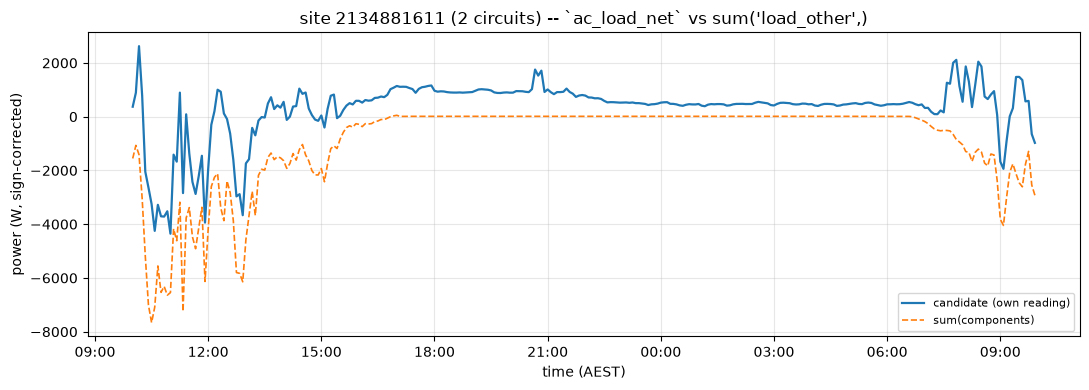

In [14]:
if aggregation_checks:
    results_table = pd.DataFrame([vars(c) for c in aggregation_checks])
    results_table["n_circuits_tested"] = results_table.component_types.apply(len) + 1
    display(results_table)

    # dropna=False: value_counts() silently drops None (inconclusive) verdicts
    # by default, which would hide them from this summary entirely.
    summary = results_table.groupby("candidate_type").is_aggregate.value_counts(dropna=False)
    print("\nVerdict counts by candidate_type:")
    print(summary)

    # Plot the SIMPLEST tested site (fewest circuits) -- easiest to read, not
    # necessarily the first one the loop happened to run. Restricted to
    # CONCLUSIVE verdicts only: an inconclusive check (too few overlapping
    # intervals) has no sum(components) line to draw, so picking on
    # n_circuits_tested alone can silently choose a site with nothing to plot.
    conclusive = results_table[results_table.is_aggregate.notna()]
    if len(conclusive):
        simplest = conclusive.sort_values("n_circuits_tested").iloc[0]
    else:
        simplest = results_table.sort_values("n_circuits_tested").iloc[0]
        print()
        print("WARNING: no conclusive aggregation check among the tested sites -- falling "
              "back to the simplest INCONCLUSIVE one; the plot below will show only one line.")
    simplest_sample = aggregation_samples[simplest.site_id]
    simplest_candidate_ids = simplest_sample[
        simplest_sample.circuit_type == simplest.candidate_type
    ].circuit_id.unique().tolist()
    simplest_component_ids = simplest_sample[
        simplest_sample.circuit_type.isin(simplest.component_types)
    ].circuit_id.unique().tolist()
    # Actual circuit-id count, not len(component_types)+1 -- a circuit_type
    # can map to more than one circuit_id at a site (seen in real data: three
    # separate circuit_ids all tagged `ac_load_net` at one site), which the
    # type-count undercounts.
    simplest_n_circuits = len(simplest_candidate_ids) + len(simplest_component_ids)
    fig, ax = Plots.plot_aggregation_check(
        simplest_sample, candidate_circuit_ids=simplest_candidate_ids,
        component_circuit_ids=simplest_component_ids,
        title=f"site {simplest.site_id} ({simplest_n_circuits} circuits) -- "
              f"`{simplest.candidate_type}` vs sum{simplest.component_types}",
    )
    plt.show()
else:
    print("No aggregation checks ran -- nothing to display.")


## 5. Circuit-polarity sign-convention verification

Reuses the real samples already pulled in section 4 -- no new query. Checks,
per circuit_type, whether `power * circuit_polarity` is consistently one
sign (confirming the fixed-sign assumption Stage 1 makes for PV) or
genuinely bidirectional (a real signal for `ami_config.STORAGE_HANDLING`, or
for an unexpectedly bidirectional "load", not just a name match).


In [15]:
if aggregation_samples:
    combined_sample = pd.concat(aggregation_samples.values(), ignore_index=True)
    polarity_check = Signal.verify_polarity_makes_positive(combined_sample)
    display(polarity_check)

    bidirectional_types = polarity_check[polarity_check.bidirectional].circuit_type.tolist()
    if bidirectional_types:
        print(f"\nBIDIRECTIONAL circuit_type(s) found: {bidirectional_types} -- "
              "confirmed by data, not just by name. If any of these is your dominant "
              "gross_load/pv_generation candidate, this needs resolving before Phase 4: "
              "a meter that is negative a third of the time is not behaving as a pure "
              "consumption/generation signal.")
    else:
        print("\nNo circuit_type in this sample showed real bidirectional behaviour "
              "(share on both sides of zero above the threshold).")
else:
    combined_sample = pd.DataFrame()
    print("No real samples available (RUN_AGGREGATION_CHECKS was False) -- skipped.")


,circuit_type,n,share_negative,share_positive,bidirectional
0,ac_load_net,1152,0.235243,0.764757,True
1,load_other,576,0.213542,0.786458,True
2,load_powerpoint,288,0.000000,1.000000,False



BIDIRECTIONAL circuit_type(s) found: ['ac_load_net', 'load_other'] -- confirmed by data, not just by name. If any of these is your dominant gross_load/pv_generation candidate, this needs resolving before Phase 4: a meter that is negative a third of the time is not behaving as a pure consumption/generation signal.


## 6. Which source column is power, which is energy -- verified

Same reused sample. Compares the two unit hypotheses for `energy_reactive`
by their implied reactive/active ratio plausibility (see
`ami_resample.verify_column_units`'s docstring for why a capacity-violation
check alone cannot distinguish them).


In [16]:
if len(combined_sample):
    units_verdict = Resample.verify_column_units(combined_sample)
    for key, value in units_verdict.items():
        print(f"{key}: {value}")
else:
    units_verdict = {"verdict": None, "reason": "no sample available"}
    print("No real sample available -- skipped.")


share_implausible_hypothesis_A: 0.017857142857142856
share_implausible_hypothesis_B: 0.15476190476190477
verdict: A (5-minute kvarh -- x12 needed)
margin_is_thin: False
reason: hypothesis A: 1.8% of rows have an implausible reactive/active ratio (outside 0.02..5.0); hypothesis B: 15.5% -- A fits better


## 7. Resample-rule demonstration

Pure -- no query. Takes one real circuit's 5-minute `power` readings from the
sample already pulled and resamples to a 30-minute bucket via
`Resample.resample_to_interval`, printing the raw values alongside the
bucketed result so the arithmetic can be eyeballed, not just trusted.


In [17]:
if len(combined_sample):
    demo_circuit_id = combined_sample.circuit_id.iloc[0]
    demo = combined_sample[combined_sample.circuit_id == demo_circuit_id].sort_values("t_stamp")
    first_half_hour = demo.head(6)[["t_stamp", "power"]]
    print(f"circuit {demo_circuit_id} -- first half hour, raw 5-min power (W):")
    display(first_half_hour)

    hand_check_kwh = sum(
        Resample.interval_energy_kwh(pd.Series([p]), source_interval_minutes=5).iloc[0]
        for p in first_half_hour.power
    )
    print(f"hand-summed energy for these 6 intervals: {hand_check_kwh:.4f} kWh")

    resampled = Resample.resample_to_interval(
        demo[["t_stamp", "power"]].assign(circuit_id=demo_circuit_id),
        time_column="t_stamp", group_columns=["circuit_id"],
        energy_like_columns={"power": False},
        source_interval_minutes=Config.SOURCE_INTERVAL_MINUTES,
        target_interval_minutes=30,
    )
    print("\n`resample_to_interval`'s first 30-min bucket:")
    display(resampled.head(1))
else:
    print("No real sample available -- skipped.")


circuit 659110 -- first half hour, raw 5-min power (W):


,t_stamp,power
0,2025-06-01 00:00:00,370.13
1,2025-06-01 00:05:00,889.42
2,2025-06-01 00:10:00,2623.19
3,2025-06-01 00:15:00,789.73
4,2025-06-01 00:20:00,-2049.73
5,2025-06-01 00:25:00,-2632.17


hand-summed energy for these 6 intervals: -0.0008 kWh

`resample_to_interval`'s first 30-min bucket:


,circuit_id,t_stamp,power
0,659110,2025-06-01,-0.000786


## 8. Example daily curves -- unpack one site's circuits

Set `INSPECT_SITE_ID` below to any site_id you want to look at -- defaults
to the simplest CONCLUSIVE site from section 4, but this is not limited to
that site; change the id and re-run this cell to unpack a different one.

Unlike section 4 (which only pulls the candidate type plus its declared
load-side siblings), this section pulls **every circuit_id present at the
site**, on both sides of the meter, by querying `meta_up23c` for the site's
full roster first -- circuit COUNT here means distinct `circuit_id`, not
distinct `circuit_type` (a real fleet pattern this caught: one site had
THREE separate circuit_ids all sharing the `ac_load_net` type, which a
type-based count would silently under-report as one).

It also runs `ami_taxonomy.find_duplicate_circuits` on whatever comes back:
a real finding this surfaced is two circuit_ids at one site -- one tagged a
load type, one tagged the PV type -- whose RAW readings were identical up to
a sign flip, i.e. the same physical circuit double-tagged, not two genuinely
separate signals. Summing that "load" into `gross_load` would double-count
the PV reading with a sign error. This check is cheap (reuses the data this
cell already pulled, no new query) and worth reading before trusting "sum of
all loads besides PV" at any site.

**Expected scan volume:** up to 2 small queries (one per `is_pv` side actually
present at the site), each pruned to this one site's circuit_ids over one
day -- the same few-MB-per-query pattern as every other query in this
notebook.


All circuits at site 2134881611 (from meta_up23c) -- 3 distinct circuit_id(s):


,circuit_id,circuit_type,is_pv,circuit_polarity
0,659111,load_other,False,1
1,659112,pv_site_net,True,-1
2,659110,ac_load_net,False,1



DUPLICATE/MIRRORED CIRCUITS DETECTED at this site -- these circuit_ids are reading the same physical signal, not independent circuits:


,site_id,circuit_id_a,circuit_id_b,correlation,sign,n_overlap
0,2134881611,659111,659112,1.0,same,288


Summing a flagged pair into `gross_load` double-counts one of them (with a sign error if `sign=opposite`) -- resolve which circuit_id is the real one before using either in the synthetic dataset.



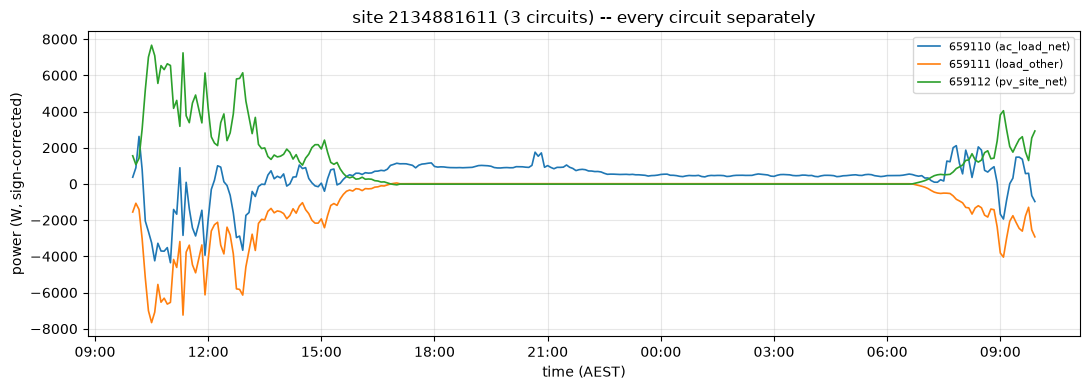

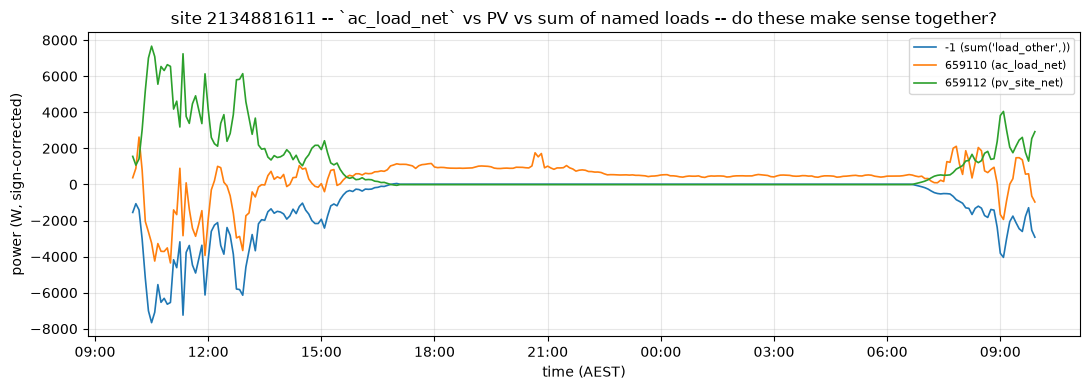

In [18]:
if aggregation_checks:
    INSPECT_SITE_ID = simplest.site_id  # <-- change this to unpack a different site

    site_all_meta = meta_local[meta_local.site_id == INSPECT_SITE_ID]
    n_site_circuits = site_all_meta.circuit_id.nunique()
    print(f"All circuits at site {INSPECT_SITE_ID} (from meta_up23c) -- "
          f"{n_site_circuits} distinct circuit_id(s):")
    display(site_all_meta[["circuit_id", "circuit_type", "is_pv", "circuit_polarity"]]
            .reset_index(drop=True))
    print()

    # Pull EVERY circuit_id at this site, whichever side of the meter it is
    # on -- `is_pv` is a partition column, so one query per side actually
    # present, not one query per named role the way section 4 does it.
    site_pulls = []
    for is_pv_value in (False, True):
        side_ids = site_all_meta[site_all_meta.is_pv == is_pv_value].circuit_id.tolist()
        if not side_ids:
            continue
        id_list_sql = ", ".join(str(int(c)) for c in side_ids)
        is_pv_sql = "true" if is_pv_value else "false"
        pulled = Athena.aq(
            f"""
            SELECT circuit_id, t_stamp, power, energy_reactive, voltage
            FROM ts
            WHERE year = {AGGREGATION_YEAR} AND month = {AGGREGATION_MONTH} AND is_pv = {is_pv_sql}
              AND circuit_id IN ({id_list_sql})
              AND t_stamp >= TIMESTAMP '{AGGREGATION_DAY_START}'
              AND t_stamp <  TIMESTAMP '{AGGREGATION_DAY_END}'
            ORDER BY circuit_id, t_stamp
            """,
            database=Config.SAI,
            label=f"site inspection, site {INSPECT_SITE_ID}, is_pv={is_pv_value}",
        )
        site_pulls.append(pulled)

    site_sample = pd.concat(site_pulls, ignore_index=True) if site_pulls else pd.DataFrame()
    if len(site_sample):
        site_sample = site_sample.merge(
            site_all_meta[["circuit_id", "circuit_type", "circuit_polarity"]],
            on="circuit_id", how="left",
        )
        site_sample["power_signed"] = site_sample.power * site_sample.circuit_polarity

    # Duplicate/mirrored-circuit check -- pure post-processing on the sample
    # just pulled, no extra query. See `find_duplicate_circuits`'s docstring
    # for why this compares raw `power`, not the polarity-corrected column.
    if len(site_sample):
        dupes = Taxonomy.find_duplicate_circuits(
            site_sample.assign(site_id=INSPECT_SITE_ID)
        )
        if len(dupes):
            print("DUPLICATE/MIRRORED CIRCUITS DETECTED at this site -- these circuit_ids "
                  "are reading the same physical signal, not independent circuits:")
            display(dupes)
            print("Summing a flagged pair into `gross_load` double-counts one of them "
                  "(with a sign error if `sign=opposite`) -- resolve which circuit_id is "
                  "the real one before using either in the synthetic dataset.")
            print()
        else:
            print("No duplicate/mirrored circuits detected among this site's circuits.")
            print()

    # Plot 1: every circuit at this site separately, whatever its role --
    # the full picture, not just the candidate/siblings/PV roles section 4
    # happened to test.
    fig, ax = Plots.plot_circuit_day(
        site_sample,
        title=f"site {INSPECT_SITE_ID} "
              f"({site_sample.circuit_id.nunique() if len(site_sample) else 0} circuits) -- "
              "every circuit separately",
    )
    plt.show()

    # Plot 2: candidate vs PV vs sum(named siblings) -- only meaningful for a
    # site section 4 actually tested (so the candidate/sibling ROLES are
    # known, not guessed here).
    site_check = next((c for c in aggregation_checks if c.site_id == INSPECT_SITE_ID), None)
    if site_check is not None and len(site_sample):
        pv_types_here = site_all_meta[site_all_meta.is_pv.astype(bool)].circuit_type.unique().tolist()
        siblings_only = site_sample[site_sample.circuit_type.isin(site_check.component_types)]
        gross_load_ex_pv = (
            siblings_only.groupby("t_stamp", as_index=False)["power_signed"].sum()
        )
        gross_load_ex_pv["circuit_id"] = -1
        gross_load_ex_pv["circuit_type"] = f"sum{site_check.component_types}"

        candidate_only = site_sample[site_sample.circuit_type == site_check.candidate_type]
        pv_only = site_sample[site_sample.circuit_type.isin(pv_types_here)]
        comparison_frame = pd.concat(
            [candidate_only, pv_only, gross_load_ex_pv], ignore_index=True
        )
        fig, ax = Plots.plot_circuit_day(
            comparison_frame,
            title=f"site {INSPECT_SITE_ID} -- `{site_check.candidate_type}` vs PV vs sum of "
                  "named loads -- do these make sense together?",
        )
        plt.show()
    else:
        print(f"Site {INSPECT_SITE_ID} was not one of section 4's tested sites (no known "
              "candidate/sibling roles to compare) -- showing the all-circuits plot only.")
else:
    print("No real samples available -- skipped.")


## 9. Does `pv_site_net` mean pure generation, or net-of-load?

Section 1 found `pv_site_net` dominates the PV side (99.6% of PV-side
circuits) and matches the "suspected aggregate" name pattern, so section 4
could not test it against real PV-side siblings -- fleet-wide there are
essentially none outside the single `pv_inverter` site. That leaves it
UNTESTED, not proven either way, and its shape in earlier runs (deeply
negative overnight, ramping toward positive during the day) is exactly what
you'd see from either hypothesis, so eyeballing one plot cannot settle it.

This section runs a check that does not need siblings: real PV generation is
~0 W in the dead of night, at every site, because there is no sunlight to
produce it -- a signal that is instead LARGE and negative overnight,
comparable to a household's normal night-time consumption, is not pure
generation; it is net of load. Where the same site also has a real load
candidate sample, the check additionally asks whether that load's own
night-time reading corroborates the size of the PV deficit -- corroborating
evidence only, not independent proof (see
`ami_signal.compare_pv_night_to_load`'s docstring for why).

**Expected scan volume:** up to `N_PV_DIAGNOSTIC_SITES` x 2 queries (the PV
candidate circuit, and the co-located load candidate circuit, at the same
site), each pruned to one site's circuit_ids over the SAME day as section 4,
with the `year`/`month`/`is_pv` partition predicate -- the same few-MB-per-
query pattern as section 4. Set `RUN_PV_NIGHT_DIAGNOSTIC = False` below to
skip all live queries in this section.


  site 130538: PV verdict=generation-like -- night mean -0.8 W is within +/-100 W of zero -- consistent with near-zero PV output overnight (at most inverter standby draw)
  site 1002469: PV verdict=None -- no sample, or missing time column
  site 1024617: PV verdict=generation-like -- night mean -1.0 W is within +/-100 W of zero -- consistent with near-zero PV output overnight (at most inverter standby draw)


,site_id,pv_candidate_type,load_candidate_type,pv_night_mean,pv_verdict,pv_reason,load_night_mean,corroborated,corroboration_reason
0,130538,pv_site_net,ac_load_net,-0.828697,generation-like,night mean -0.8 W is within +/-100 W of zero -...,1997.766478,None,PV verdict is not net-like -- no net-of-load h...
1,1002469,pv_site_net,ac_load_net,NaN,NaN,"no sample, or missing time column",NaN,None,PV verdict is not net-like -- no net-of-load h...
2,1024617,pv_site_net,ac_load_net,-0.988119,generation-like,night mean -1.0 W is within +/-100 W of zero -...,-366.392933,None,PV verdict is not net-like -- no net-of-load h...



0 of 3 tested site(s) show `pv_site_net` behaving NET-LIKE at night; 2 show GENERATION-LIKE behaviour. A verdict that varies by site is itself a finding, the same way section 4's aggregation verdicts are read.


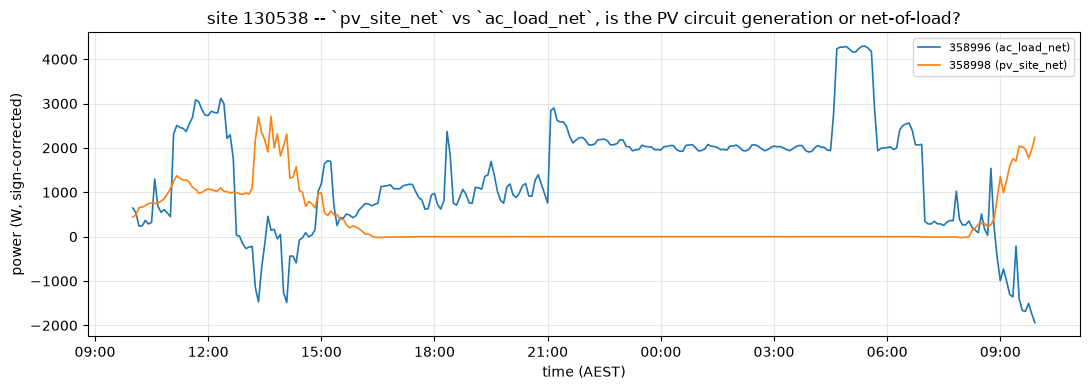

In [19]:
RUN_PV_NIGHT_DIAGNOSTIC = True  # set False to skip -- see the cost note above
N_PV_DIAGNOSTIC_SITES = 3
NIGHT_HOUR_START, NIGHT_HOUR_END = 1, 4  # AEST -- well inside guaranteed darkness fleet-wide

pv_night_results = []
pv_night_samples = {}  # site_id -> concatenated PV + load sample, for the example plot below

if RUN_PV_NIGHT_DIAGNOSTIC:
    pv_suspects = suspects[suspects.is_pv.astype(bool)].circuit_type.tolist()
    load_suspects = suspects[~suspects.is_pv.astype(bool)].circuit_type.tolist()

    if not pv_suspects:
        print("No PV-side circuit_type flagged as a suspected aggregate -- nothing to diagnose here.")
    else:
        pv_candidate_type = pv_suspects[0]
        load_candidate_type = load_suspects[0] if load_suspects else None

        diagnostic_sites = cohort_with_both[
            cohort_with_both[pv_candidate_type] > 0
        ].site_id.tolist()[:N_PV_DIAGNOSTIC_SITES] if pv_candidate_type in cohort_with_both.columns else []

        if not diagnostic_sites:
            print(f"No site in `cohort_with_both` has `{pv_candidate_type}` -- skipping.")

        def _pull_signed(site_meta, circuit_ids, is_pv_value, site_id):
            if not circuit_ids:
                return pd.DataFrame()
            id_list_sql = ", ".join(str(int(c)) for c in circuit_ids)
            is_pv_sql = "true" if is_pv_value else "false"
            raw = Athena.aq(
                f"""
                SELECT circuit_id, t_stamp, power, energy_reactive, voltage
                FROM ts
                WHERE year = {AGGREGATION_YEAR} AND month = {AGGREGATION_MONTH} AND is_pv = {is_pv_sql}
                  AND circuit_id IN ({id_list_sql})
                  AND t_stamp >= TIMESTAMP '{AGGREGATION_DAY_START}'
                  AND t_stamp <  TIMESTAMP '{AGGREGATION_DAY_END}'
                ORDER BY circuit_id, t_stamp
                """,
                database=Config.SAI,
                label=f"PV night diagnostic, site {site_id}, is_pv={is_pv_value}",
            )
            raw = raw.merge(
                site_meta[["circuit_id", "circuit_type", "circuit_polarity"]],
                on="circuit_id", how="left",
            )
            raw["power_signed"] = raw.power * raw.circuit_polarity
            raw["_t_aest"] = Plots.to_aest(raw.t_stamp)
            return raw

        for site_id in diagnostic_sites:
            site_meta = meta_local[meta_local.site_id == site_id]
            pv_ids = site_meta[site_meta.circuit_type == pv_candidate_type].circuit_id.tolist()
            load_ids = (
                site_meta[site_meta.circuit_type == load_candidate_type].circuit_id.tolist()
                if load_candidate_type else []
            )

            pv_sample = _pull_signed(site_meta, pv_ids, True, site_id)
            load_sample = _pull_signed(site_meta, load_ids, False, site_id)
            pv_night_samples[site_id] = pd.concat([pv_sample, load_sample], ignore_index=True)

            pv_stats = Signal.classify_pv_night_behaviour(
                pv_sample, time_column="_t_aest",
                night_hour_start=NIGHT_HOUR_START, night_hour_end=NIGHT_HOUR_END,
            )
            load_stats = Signal.night_window_stats(
                load_sample, time_column="_t_aest",
                night_hour_start=NIGHT_HOUR_START, night_hour_end=NIGHT_HOUR_END,
            )
            corroboration = Signal.compare_pv_night_to_load(pv_stats, load_stats)

            pv_night_results.append({
                "site_id": site_id,
                "pv_candidate_type": pv_candidate_type,
                "load_candidate_type": load_candidate_type,
                "pv_night_mean": pv_stats.get("night_mean"),
                "pv_verdict": pv_stats.get("verdict"),
                "pv_reason": pv_stats.get("reason"),
                "load_night_mean": load_stats.get("night_mean"),
                "corroborated": corroboration.get("corroborated"),
                "corroboration_reason": corroboration.get("reason"),
            })
            print(f"  site {site_id}: PV verdict={pv_stats.get('verdict')} -- {pv_stats.get('reason')}")

        if pv_night_results:
            pv_night_table = pd.DataFrame(pv_night_results)
            display(pv_night_table)

            n_net_like = (pv_night_table.pv_verdict == "net-like").sum()
            n_generation_like = (pv_night_table.pv_verdict == "generation-like").sum()
            print(f"\n{n_net_like} of {len(pv_night_table)} tested site(s) show `{pv_candidate_type}` "
                  f"behaving NET-LIKE at night; {n_generation_like} show GENERATION-LIKE behaviour. "
                  "A verdict that varies by site is itself a finding, the same way section 4's "
                  "aggregation verdicts are read.")

            net_like_rows = pv_night_table[pv_night_table.pv_verdict == "net-like"]
            example_site_id = (
                net_like_rows.iloc[0].site_id if len(net_like_rows) else pv_night_table.iloc[0].site_id
            )
            fig, ax = Plots.plot_circuit_day(
                pv_night_samples[example_site_id],
                title=f"site {example_site_id} -- `{pv_candidate_type}` vs `{load_candidate_type}`, "
                      "is the PV circuit generation or net-of-load?",
            )
            plt.show()
        else:
            pv_night_table = pd.DataFrame()
else:
    pv_night_table = pd.DataFrame()
    print("RUN_PV_NIGHT_DIAGNOSTIC is False -- skipped.")


In [ ]:
display(Athena.scan_report())

28 queries, 2.24 GB scanned, ~AUD 0.0181 (billed at a 10.00 MB minimum per query)


,label,database,n_rows,seconds,scanned,scanned_bytes,cost,source
0,circuit_type census,solar_analytics_iceberg,33,2.02,1.14 MB,1194973.0,0.0001,query_metadata
1,meta_up23c full projection,solar_analytics_iceberg,60570,3.29,2.21 MB,2322034.0,0.0001,query_metadata
2,"aggregation test sample, site 2064693465",solar_analytics_iceberg,4320,3.04,160.11 MB,167892093.0,0.0012,query_metadata
3,"aggregation test sample, site 856379665",solar_analytics_iceberg,5181,3.21,127.96 MB,134170971.0,0.0010,query_metadata
4,"aggregation test sample, site 2136269794",solar_analytics_iceberg,576,2.90,159.95 MB,167723755.0,0.0012,query_metadata
5,"aggregation test sample, site 16356828",solar_analytics_iceberg,288,2.89,221.71 MB,232475643.0,0.0017,query_metadata
6,"site inspection, site 2136269794, is_pv=False",solar_analytics_iceberg,576,4.05,159.95 MB,167723755.0,0.0012,query_metadata
7,"site inspection, site 2136269794, is_pv=True",solar_analytics_iceberg,288,2.91,118.35 MB,124098593.0,0.0009,query_metadata
8,"PV night diagnostic, site 130538, is_pv=True",solar_analytics_iceberg,288,3.36,74.47 MB,78088405.0,0.0006,query_metadata
9,"PV night diagnostic, site 130538, is_pv=False",solar_analytics_iceberg,288,3.16,33.58 MB,35214339.0,0.0003,query_metadata


## 10. Summary -- pending your run

*(This section is written before you have run the notebook. I will revise it
to state actual findings, the same way notebooks 01 and 02's closing sections
were only finalised after you ran them -- placeholders below, not conclusions.)*

**What this notebook needs to tell us, and what I'll do with each once you've
run it and shared the output:**

- **Aggregation verdicts (section 4), across a spread of sites, not one.**
  A consistent verdict across all tested sites for a candidate_type resolves
  it (excluded into `ami_config.AGGREGATE_CIRCUIT_TYPES`, or kept as an
  ordinary signal). A verdict that varies by site is itself a finding worth
  discussing before Phase 4, not something to average away.
- **Storage (section 2 + 5).** Any circuit_type confirmed bidirectional
  becomes `ami_config.STORAGE_HANDLING`'s answer; none found means we record
  "no storage circuits identified in this fleet" rather than leaving the
  placeholder silently unresolved.
- **Column units (section 6).** Whichever hypothesis wins becomes
  `ami_config.SOURCE_COLUMN_UNITS_RESOLVED = True`, with the losing
  hypothesis's implausibility share recorded as the evidence. A thin margin
  (`margin_is_thin=True`) means re-testing on a bigger sample before trusting
  it, not accepting a coin-flip.
- **Fleet coverage (section 3).** `signal_coverage_summary`'s numbers go into
  `ami_config.py` as a Phase 3 finding, informing how much of the fleet Phase
  4/5 can actually build ground truth for.
- **PV signal semantics (section 9).** Whether `pv_site_net` (or whichever
  dominant PV candidate) behaves as pure generation or net-of-load determines
  how Phase 5 builds the `pv_generation` ground-truth signal -- a net-like
  verdict means this circuit cannot be used as generation ground truth as-is,
  and a separate net-of-load construction (or a different PV source column
  entirely) needs deciding before Phase 4.
- **Target interval.** Still your call, not something arithmetic decides --
  the 30-minute placeholder stands unless you say otherwise.

Once you've run this and shared what came back, I'll write the confirmed
values into `ami_config.py` (mirroring how Phase 1's and Phase 2's findings
were only written in after you'd seen and agreed with them), update
`ARCHITECTURE.md`'s phase-status row, and this section gets rewritten to
state the actual findings before we move to Phase 4.
